In [1]:
import pandas as pd
df = pd.read_csv('ml_dataset_with_weather.csv')

# One hot encoding Day of Week

In [2]:
df = pd.get_dummies(df, columns=['Day of Week'], drop_first=True)

In [3]:
print(df.shape)
print(df.head())
print(df.columns.tolist())
print(df.dtypes)

(15517, 21)
         Date            LHD     Hospital Name  Postcode  COVID Cases  \
0  2026-01-01  Central Coast  Gosford Hospital      2250            7   
1  2026-01-02  Central Coast  Gosford Hospital      2250            7   
2  2026-01-03  Central Coast  Gosford Hospital      2250            7   
3  2026-01-04  Central Coast  Gosford Hospital      2250            5   
4  2026-01-05  Central Coast  Gosford Hospital      2250            5   

   RSV Cases  Influenza Cases  Average Persons Waiting  Combined Cases  \
0          4                9                    16.82              20   
1          4                9                    16.85              20   
2          4                9                    10.84              20   
3          4                7                     7.26              16   
4          4                7                    11.73              16   

   temperature_max  ...  precipitation_sum  relative_humidity_min  \
0             19.2  ...            

# XGBOOST

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from xgboost import XGBRegressor

# 1. Prepare Categorical & String Data
df = df.drop(columns=['Date'])

# One-hot encode the LHD and Hospital Name strings
df = pd.get_dummies(df, columns=['LHD', 'Hospital Name'], drop_first=True)

# Convert boolean Day of Week columns to 1/0 integers
bool_cols = [col for col in df.columns if 'Day of Week' in col]
df[bool_cols] = df[bool_cols].astype(int)

# 2. Define Features (X) and Target (y)
X = df.drop(columns=['Average Persons Waiting'])
y = df['Average Persons Waiting']

# 3. 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Initialise and Train XGBoost
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1  
)

xgb_model.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred = xgb_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("XGBoost Performance measrurement")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

XGBoost Performance measrurement
RMSE: 2.2059
R²:   0.7665


## Hyperparam tuning

In [5]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# 1. Define the parameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8]
}

# 2. Initialise the base model
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

# 3. Set up the Grid Search
# cv=5 splits the training data 5 ways to validate each parameter combination
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=1
)

# 4. Fit the grid search to the training data
print("Testing parameter combos...")
grid_search.fit(X_train, y_train)

# 5. Extract the best model and evaluate on the test set
best_xgb = grid_search.best_estimator_

print(f"\nBest Parameters Found: {grid_search.best_params_}")

y_pred_best = best_xgb.predict(X_test)
best_rmse = root_mean_squared_error(y_test, y_pred_best)
best_r2 = r2_score(y_test, y_pred_best)

print("\n hyperparam tuning XGB")
print(f"RMSE: {best_rmse:.4f}")
print(f"R²:   {best_r2:.4f}")

Testing parameter combos...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best Parameters Found: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500}

 hyperparam tuning XGB
RMSE: 2.2380
R²:   0.7596


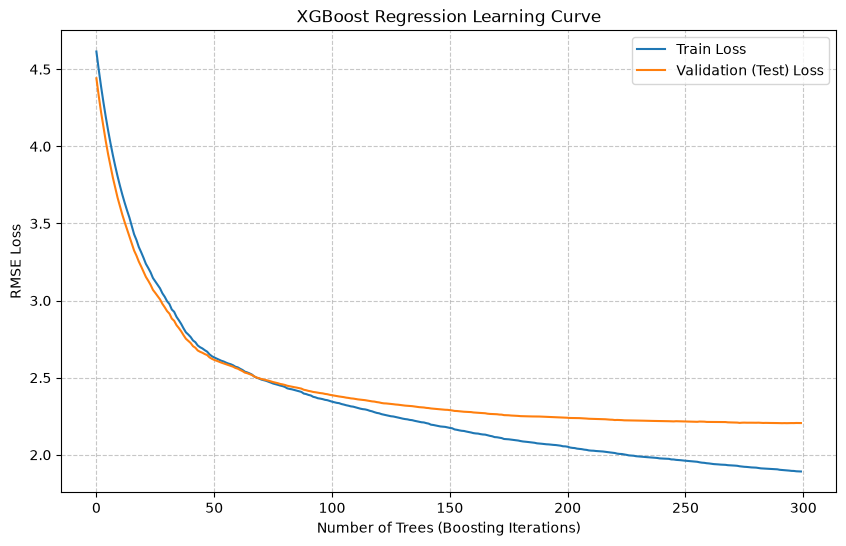

In [6]:
import matplotlib.pyplot as plt

# 1.datasets to evaluate during training
eval_set = [(X_train, y_train), (X_test, y_test)]

# 2. Fit the model while tracking the loss
xgb_model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False # Set to True if you want to see the text output per iteration
)

# 3. Extract the loss history
results = xgb_model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

# 4. Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train Loss')
plt.plot(x_axis, results['validation_1']['rmse'], label='Validation (Test) Loss')
plt.xlabel('Number of Trees (Boosting Iterations)')
plt.ylabel('RMSE Loss')
plt.title('XGBoost Regression Learning Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# LINEAR

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Assuming X and y are already defined from your previous setup:
# X = df[base_features + day_features]
# y = df['ed_waiting_average']

# 1. 80/20 Train/Test Split[cite: 1, 3]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Build the Linear Pipeline
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0)) # alpha controls the regularization strength
])

# 3. Train the Model
ridge_pipe.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred_ridge = ridge_pipe.predict(X_test)
ridge_rmse = root_mean_squared_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Linear Ridge Baseline")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"R²:   {ridge_r2:.4f}")

Linear Ridge Baseline
RMSE: 2.7353
R²:   0.6409


In [8]:
import joblib

# Save the best model or pipeline
joblib.dump(best_xgb, "best_xgboost_model.pkl")

# Load the model later
loaded_model = joblib.load("best_xgboost_model.pkl")